# Module 1 - Nonlinear Stability Definitions

This module introduces the mathematical language used to describe the **stability of nonlinear dynamical systems**. The central question is:

> If a system is disturbed from a desired reference motion or equilibrium, does it remain nearby, return to it, or move further away?

The discussion begins by defining the **state**, **equations of motion**, **reference motion**, **equilibrium**, and **neighborhood** of a state. These concepts are then used to distinguish between **Lagrange stability**, **Lyapunov stability**, and **asymptotic stability**.

A key feature of nonlinear systems is that stability may depend on the size of the initial disturbance. A system may be stable for states close to an equilibrium but behave differently for larger departures. This motivates the distinction between **local** and **global** stability.

The module concludes by introducing **linearization** as a local analysis tool. Linearization approximates the nonlinear dynamics near a reference motion or equilibrium, allowing familiar linear-system methods to provide local information about the original nonlinear system.

These ideas form the foundation for later analysis of nonlinear spacecraft attitude dynamics and control.

**<ins>Learning Objectives</ins>**

- define the state, reference motion, equilibrium, and neighborhood of a dynamical system;
- distinguish between **Lagrange**, **Lyapunov**, and **asymptotic** stability;
- explain the difference between **local** and **global** stability claims;
- formulate departure variables relative to a reference motion or equilibrium;
- derive a first-order linearized model and explain why its stability conclusions are local.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1.1 - From Classical Linear Control to Nonlinear Stability

Before defining nonlinear stability, it is useful to recall how stability is treated in linear control.

This section is not intended to be a complete review of classical control theory. Its purpose is to establish the sequence of ideas that leads to nonlinear stability analysis:

$$
\text{mathematical model}
\;\longrightarrow\;
\text{feedback}
\;\longrightarrow\;
\text{closed-loop dynamics}
\;\longrightarrow\;
\text{stability analysis}.
$$

Linear control provides powerful tools for studying systems whose dynamics are either exactly linear or adequately approximated as linear near an operating point. Nonlinear stability theory extends the same fundamental questions to systems whose full dynamics cannot be represented by one linear model.

## 1.1.1 - Classical Linear Tools

Classical control theory was developed primarily around **linear time-invariant systems (LTI)**.

A system is linear when its input-output relationship satisfies **superposition**. If the inputs $u_1(t)$ and $u_2(t)$ produce outputs $y_1(t)$ and $y_2(t)$, then

$$
a u_1(t)+b u_2(t)
\quad\longrightarrow\quad
a y_1(t)+b y_2(t)
$$

for arbitrary constants $a$ and $b$.

A system is time-invariant when its governing behavior does not change explicitly with time. Delaying an input therefore produces an equivalent delay in the output.

These properties make linear systems mathematically convenient. Differential equations can be transformed into algebraic equations using the Laplace transform, allowing the system to be represented by a **transfer function**:

$$
G(s)=\frac{Y(s)}{U(s)}.
$$

For a rational transfer function,

$$
G(s) =
\frac{b_m s^m+\cdots+b_1s+b_0}
     {a_n s^n+\cdots+a_1s+a_0},
$$

the roots of the denominator are the system **poles**. Their locations describe the natural modes of the linear system and are central to determining its stability and transient response.

Frequency-domain tools such as Bode plots, Nyquist plots, and root locus provide additional ways to study stability, robustness, and performance without explicitly solving the differential equations.

**<ins>Why these tools matter</ins>**

For an exact linear model, these methods provide strong and often global conclusions about that model. The difficulty begins when the physical system is nonlinear and the linear model is only an approximation valid near one operating condition.

## 1.1.2 - Feedback Control

The central idea of control is **feedback**.

A measured output $y(t)$ is compared with a desired reference $r(t)$ to form an error:

$$
e(t)=r(t)-y(t).
$$

The controller uses this error, or an equivalent state-error quantity, to determine the control input:

$$
u(t)=\mathcal{C}\bigl(e(t)\bigr),
$$

where $\mathcal{C}$ represents the chosen control law.

In an open-loop system, the applied input does not depend on the measured response. Disturbances, uncertainty, or modeling errors therefore act without automatic correction.

In a closed-loop system, the control input depends on the observed system behavior:

$$
\text{reference}
\rightarrow
\text{controller}
\rightarrow
\text{plant}
\rightarrow
\text{measurement}
\rightarrow
\text{controller}.
$$

The controller therefore becomes part of the system dynamics.

A **PID controller** is one familiar implementation of this principle. It
combines the present error, accumulated error, and rate of change of error:

$$
u(t) = K_P e(t) + K_I\int_0^t e(\tau)\,d\tau + K_D\dot e(t).
$$

The specific controller may be PID, state feedback, or a nonlinear feedback law. The broader idea is unchanged: once the control input depends on the measured state or error, the controller becomes part of the closed-loop dynamics.

**<ins>Feedback reshapes the dynamics</ins>**

Consider a linear plant:

$$
\dot{\mathbf{x}} = A\mathbf{x}+B\mathbf{u}.
$$

Suppose the control law is state feedback:

$$
\mathbf{u}=-K\mathbf{x}.
$$

Substituting the control law into the plant dynamics gives

$$
\begin{aligned}
\dot{\mathbf{x}}
&=
A\mathbf{x}+B(-K\mathbf{x})\\
&=
(A-BK)\mathbf{x}.
\end{aligned}
$$

The open-loop dynamics are governed by $A$, while the closed-loop dynamics are governed by

$$
A_{\mathrm{cl}}=A-BK.
$$

Feedback therefore does not merely correct the output. It changes the differential equation that determines how the state evolves.

By selecting the controller, the engineer attempts to make disturbances decay, regulate the system toward a desired state, and achieve acceptable transient behavior.

**<ins>Connection to nonlinear control</ins>**

The same idea remains valid for nonlinear systems. The controller is designed so that the resulting closed-loop nonlinear dynamics possess the required stability properties. What changes is the mathematical machinery used to prove those properties.

## 1.1.3 - State-Space Formulation

Transfer functions describe how an input is mapped to an output. However, stability is fundamentally concerned with how the **internal state of the system evolves over time**.

The state vector contains the minimum information required to determine the future motion of the system once the input is known:

$$
\mathbf{x}(t) =
\begin{bmatrix}
x_1(t) & x_2(t) & \cdots & x_n(t)
\end{bmatrix}^{T}
\in\mathbb{R}^{n}.
$$

For a continuous-time linear system,

$$
\dot{\mathbf{x}}(t) = A\mathbf{x}(t)+B\mathbf{u}(t),
$$

with output equation

$$
\mathbf{y}(t) = C\mathbf{x}(t)+D\mathbf{u}(t),
$$

where

$$
\begin{aligned}
\mathbf{x}&\in\mathbb{R}^{n},
&
\mathbf{u}&\in\mathbb{R}^{m},
&
\mathbf{y}&\in\mathbb{R}^{p},\\
A&\in\mathbb{R}^{n\times n},
&
B&\in\mathbb{R}^{n\times m},
&
C&\in\mathbb{R}^{p\times n},
&
D&\in\mathbb{R}^{p\times m}.
\end{aligned}
$$

The matrix $A$ describes the natural state evolution, while $B$ describes how the control input influences that evolution.

For example, the state of a mechanical system may include position and velocity. A spacecraft-attitude state may contain an attitude representation and angular velocity.

**<ins>Why state space is needed for stability analysis</ins>**

The state-space formulation shifts the central question from

> How does the input affect the output?

to

> How does the complete system state evolve relative to a desired motion or equilibrium?

For the unforced linear system

$$
\dot{\mathbf{x}}=A\mathbf{x},
$$

the eigenvalues of $A$ describe the system modes.

If every eigenvalue satisfies

$$
\operatorname{Re}(\lambda_i)<0,
$$

then every mode decays and the equilibrium $\mathbf{x}=\mathbf{0}$ is exponentially stable.

If at least one eigenvalue satisfies

$$
\operatorname{Re}(\lambda_i)>0,
$$

then at least one mode grows and the equilibrium is unstable.

Cases involving eigenvalues on the imaginary axis require additional care and cannot be classified using only the simple strict-sign test above.

**<ins>Bridge to nonlinear state space</ins>**

A nonlinear controlled system is written more generally as

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u},t).
$$

The constant matrices $A$ and $B$ are replaced by a nonlinear vector-valued function $\mathbf{f}$.

The state-space viewpoint therefore carries naturally into nonlinear control. However, the linear eigenvalue test no longer provides a complete description of the nonlinear system's behavior.

## 1.1.4 - Limitations of Linear Control Analysis

Linear control methods are powerful when the system is accurately represented by a linear model.

An important distinction must therefore be made.

**<ins>Exact linear system</ins>**

If the physical model is exactly

$$
\dot{\mathbf{x}} = A\mathbf{x}+B\mathbf{u},
$$

then the resulting linear stability conclusions apply to the full mathematical model. They are not merely local conclusions.

**<ins>Linearized nonlinear system</ins>**

A nonlinear system has the form

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u},t).
$$

Near a selected reference motion or equilibrium, the nonlinear dynamics may be approximated by a linear model:

$$
\delta\dot{\mathbf{x}} \approx A(t)\delta\mathbf{x} + B(t)\delta\mathbf{u}.
$$

This approximation neglects higher-order terms. Its accuracy therefore depends on the size of the departure variables $\delta\mathbf{x}$ and $\delta\mathbf{u}$.

The resulting linear stability analysis provides information about the nonlinear system only within a sufficiently small neighborhood of the reference motion.

**<ins>Why this matters for spacecraft attitude dynamics</ins>**

Rigid-body attitude dynamics contain explicitly nonlinear terms. For example,

$$
I\dot{\boldsymbol{\omega}} + \boldsymbol{\omega}\times I\boldsymbol{\omega} = \mathbf{u},
$$

where the gyroscopic coupling term

$$
\boldsymbol{\omega}\times I\boldsymbol{\omega}
$$

is nonlinear in angular velocity.

Spacecraft attitude also evolves on the rotation group $SO(3)$ rather than in an unrestricted Euclidean vector space. This introduces features that one local linear model cannot fully capture, including:

- large-angle rotational motion;
- multiple or equivalent attitude representations;
- coordinate singularities;
- multiple equilibrium configurations;
- actuator torque and momentum limits;
- state-dependent coupling between rotational axes.

A linearized model may accurately describe small attitude and rate errors while failing to represent behavior during a large slew or near a coordinate singularity.

**<ins>What nonlinear stability analysis adds</ins>**

Nonlinear stability theory works directly with

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u},t)
$$

and asks whether the full nonlinear trajectories:

- remain bounded;
- remain close to a reference motion;
- converge toward an equilibrium;
- satisfy these properties locally, globally, or almost globally.

This does not make linear control obsolete. Linear analysis remains valuable for local behavior, gain selection, performance prediction, and controller implementation.

Nonlinear analysis extends these tools by determining what can be guaranteed when the full nonlinear structure cannot be neglected.

**<ins>Section takeaway</ins>**

The progression from linear to nonlinear control is

$$
\boxed{
\text{linear model}
\rightarrow
\text{feedback}
\rightarrow
\text{closed-loop state dynamics}
\rightarrow
\text{local linear analysis}
\rightarrow
\text{nonlinear stability analysis}
}
$$

The central question remains unchanged:

> Under the closed-loop dynamics, what happens to a state that is disturbed from its desired motion?

# 1.2 - Mathematical Language of Nonlinear Systems

Before asking whether a system is stable, we need a precise language for describing:

1. the system's current condition;
2. how that condition evolves;
3. the motion or state we want to compare it against; and
4. what it means to be close to that reference.

The central mathematical objects are therefore

$$
\boxed{
\text{state}
\rightarrow
\text{dynamics}
\rightarrow
\text{reference motion}
\rightarrow
\text{departure from the reference}
}
$$

These definitions allow qualitative statements such as “the spacecraft remains
near the commanded attitude” to be written as precise mathematical conditions.

## 1.2.1 - Dynamical Systems

A **dynamical system** is a mathematical rule that describes how a system changes with time.

The **state vector** is simply the collection of variables used to describe the system at a particular instant:

$$
\mathbf{x} =
\begin{bmatrix}
x_1 & x_2 & \cdots & x_N
\end{bmatrix}^{T}
\in\mathbb{R}^{N}.
$$

The variables included in $\mathbf{x}$ depend on the problem being studied.

For example, the state of a mechanical system may contain position and velocity. A spacecraft attitude state may contain an attitude representation and angular velocity.

More formally, a valid state must contain enough information to determine the future motion of the model once the future inputs are specified.

The **equations of motion** describe how the state changes:

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},t).
$$

The function $\mathbf{f}$ assigns a state rate $\dot{\mathbf{x}}$ to each state $\mathbf{x}$ and time $t$.

**<ins>Autonomous systems</ins>**

An autonomous system has no explicit dependence on time:

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}).
$$

At a given state $\mathbf{x}$, the system always produces the same state rate $\dot{\mathbf{x}}$, regardless of when that state is reached.

The function $\mathbf{f}(\mathbf{x})$ therefore defines a **vector field** over the state space. At each point $\mathbf{x}$, the vector $\dot{\mathbf{x}}$ tells us the instantaneous direction and rate of motion.

Starting from an initial condition $\mathbf{x}(t_0)$, the system follows this vector field and traces out a trajectory $\mathbf{x}(t)$.

**<ins>Non-autonomous systems</ins>**

A non-autonomous system depends explicitly on time:

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},t).
$$

The same state may therefore produce a different state rate at different times.

This can occur when the environment, reference command, system parameters, or external forcing changes with time.

**<ins>Controlled systems</ins>**

When control inputs are included, the dynamics are written as

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u},t),
$$

where

$$
\mathbf{u}\in\mathbb{R}^{M}
$$

contains the control inputs.

For a spacecraft, $\mathbf{u}$ may represent commanded body torques produced by reaction wheels, control-moment gyroscopes, or thrusters.

Suppose the control input is generated using state feedback:

$$
\mathbf{u} = \mathbf{g}(\mathbf{x}).
$$

Substituting the control law into the equations of motion gives the closed-loop dynamics:

$$
\dot{\mathbf{x}} = \mathbf{f}\bigl(\mathbf{x},\mathbf{g}(\mathbf{x}),t\bigr).
$$

If the original dynamics have no explicit time dependence, this reduces to

$$
\dot{\mathbf{x}} = \mathbf{f}\bigl(\mathbf{x},\mathbf{g}(\mathbf{x})\bigr),
$$

which is autonomous.

The important point is that stability is studied using the **closed-loop dynamics**. Once feedback is applied, we analyze how the complete plant–controller system evolves.

## 1.2.2 - Reference Motions and Equilibrium States

Stability is always defined relative to something.

That reference may be:

- a fixed state;
- a time-varying trajectory;
- or, later in spacecraft control, a desired attitude and angular-rate motion.

A **reference motion** $\mathbf{x}_r(t)$ must itself satisfy the equations of motion under its corresponding reference input $\mathbf{u}_r(t)$:

$$
\dot{\mathbf{x}}_r =
\mathbf{f}
\bigl(
\mathbf{x}_r,
\mathbf{u}_r,
t
\bigr).
$$

This means that $\mathbf{x}_r(t)$ is a valid motion of the system, rather than an arbitrary curve drawn through the state space.

For example, a nadir-pointing spacecraft (a fancy way to say Earth-pointing) does not generally maintain one fixed inertial attitude. Its desired attitude changes as it moves around the Earth. The commanded attitude is therefore a reference motion rather than a constant state.

An **equilibrium state** is the special case in which the reference remains constant:

$$
\mathbf{x}_r(t)=\mathbf{x}_e.
$$

Because the equilibrium does not move,

$$
\dot{\mathbf{x}}_e=\mathbf{0}.
$$

For an autonomous system

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x}),
$$

the equilibrium condition is

$$
\mathbf{f}(\mathbf{x}_e)=\mathbf{0}.
$$

For a non-autonomous system, a constant state $\mathbf{x}_e$ is an equilibrium when

$$
\mathbf{f}(\mathbf{x}_e,t)=\mathbf{0}
\qquad
\forall 
t\geq t_0.
$$

If the system is initialized exactly at an equilibrium, then

$$
\mathbf{x}(t_0)=\mathbf{x}_e
\quad\Rightarrow\quad
\mathbf{x}(t)=\mathbf{x}_e
\qquad
\forall t\geq t_0.
$$

In other words, the system remains there unless it is disturbed.

**<ins>An equilibrium is not automatically stable</ins>**

The equilibrium condition only tells us that the state does not move when placed exactly at $\mathbf{x}_e$.

It does not tell us what happens after a small disturbance.

Nearby trajectories may:

- remain close;
- return to the equilibrium;
- move away from it;
- or behave differently depending on the disturbance direction.

Stability analysis is concerned with this nearby behavior.

## 1.2.3 - Neighborhoods and Departure States

To define stability, we need a precise meaning for the word “close.”

Let $\|\cdot\|$ denote a norm on the state space. The Euclidean norm (also known as $L_2$-norm)  is

$$
\|\mathbf{x}\| =
\sqrt{
x_1^2+x_2^2+\cdots+x_N^2
}.
$$

The Euclidean norm is only one way of measuring the size of a vector; other common choices include the $1$-norm, the $\infty$-norm, and weighted norms. Unless stated otherwise, this notebook uses the Euclidean norm because it gives the most familiar geometric interpretation of distance, while still being sufficient for the finite-dimensional stability concepts considered here.

The distance between the current state $\mathbf{x}(t)$ and a reference motion $\mathbf{x}_r(t)$ is

$$
\left\|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right\|.
$$

Given a radius $\delta>0$, the neighborhood of $\mathbf{x}_r(t)$ is defined as

$$
B_\delta\bigl(\mathbf{x}_r(t)\bigr) =
\left\{
\mathbf{x}\in\mathbb{R}^{N}
\;\middle|\;
\left\|
\mathbf{x}-\mathbf{x}_r(t)
\right\|<\delta
\right\}.
$$

<div align="center">
  <img src="Images/Wk1_Neighborhood.PNG" alt="Neighborhood around a reference state" width="500"/>
</div>

The statement

$$
\mathbf{x}(t)
\in
B_\delta\bigl(\mathbf{x}_r(t)\bigr)
$$

means that the current state is less than a distance $\delta$ from the reference state at that time.

**<ins>Departure state</ins>**

Instead of repeatedly comparing $\mathbf{x}(t)$ and $\mathbf{x}_r(t)$, we define the departure state

$$
\delta\mathbf{x}(t) =
\mathbf{x}(t)-\mathbf{x}_r(t).
$$

The desired motion now corresponds to

$$
\delta\mathbf{x}(t)=\mathbf{0}.
$$

Its magnitude,

$$
\|\delta\mathbf{x}(t)\|,
$$

measures how far the current state is from the reference according to the selected norm.

For an equilibrium reference,

$$
\delta\mathbf{x}(t) =
\mathbf{x}(t)-\mathbf{x}_e.
$$

For a time-varying reference,

$$
\delta\mathbf{x}(t) =
\mathbf{x}(t)-\mathbf{x}_r(t).
$$

This change of viewpoint is important. Instead of proving stability separately about every possible reference state, we study whether the departure state remains near or converges toward zero.

The stability questions can now be stated more precisely:

- If $\|\delta\mathbf{x}(t_0)\|$ is small, does it remain small?
- Does $\delta\mathbf{x}(t)$ eventually approach zero?
- Does the answer hold only near the reference, or for all admissible initial states?

These questions lead directly to the stability definitions in the next section.

# 1.3 - Stability Definitions and their Scope

Stability can mean different things depending on what we want to know about the system after it is disturbed.

We may ask whether the motion stays bounded, whether a small disturbance remains small, or whether the system eventually returns to the reference (a more interesting way of saying, "did it go back to its original position or did it settle somewhere else").

These ideas lead to the different stability definitions in this section. We will also distinguish between **local** and **global** stability, which describe how much of the state space the result applies to.

## 1.3.1 - Lagrange Stability (Boundedness)

Lagrange stability asks the most basic stability question:

> Does the motion remain bounded, or can it grow without limit?

Consider a motion $\mathbf{x}(t)$ relative to a reference motion $\mathbf{x}_r(t)$. The motion is Lagrange stable if there exists some finite $\delta>0$ such that

$$
\mathbf{x}(t)\in B_\delta\bigl(\mathbf{x}_r(t)\bigr)
\qquad
\forall,t\geq t_0.
$$

Equivalently,

$$
\left|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right|<\delta
\qquad
\forall,t\geq t_0.
$$

<div align="center"> 
    <img src="Images/Wk1_LagrangeStability.PNG" alt="Lagrange stability relative to a reference motion" width="500"/> 
</div>

**<ins>Understanding the definition</ins>**

The key point is that some finite bound $\delta$ must exist.

In the figure above, the dashed curve represents the reference motion $\mathbf{x}_r(t)$ and the blue curve represents the actual motion $\mathbf{x}(t)$. At any time $t$, the separation between them must remain smaller than the chosen bound $\delta$.

The bound does not have to be small. Lagrange stability only requires the motion to remain within some finite distance of the reference.

The trajectory may therefore wander, oscillate, or remain offset from the reference indefinitely and still be Lagrange stable.

**<ins>What Lagrange stability guarantees</ins>**

The motion remains bounded relative to the reference. The separation $|\mathbf{x}(t)-\mathbf{x}_r(t)|$ does not grow without limit.

**<ins>What it does not guarantee</ins>**

The state does not have to remain arbitrarily close to the reference. 
A small initial error does not necessarily remain small.
The state does not have to converge to the reference.

For example, an undamped harmonic oscillator can remain bounded indefinitely while continuing to oscillate without converging to its equilibrium.

In summary:

$$
\boxed{
\text{Lagrange stability}
\quad\Longrightarrow\quad
\text{bounded motion}
}
$$

It says that the motion stays within some finite bound. It does not yet tell us whether a small disturbance stays small or whether the state eventually returns to the reference. Those stronger questions lead to Lyapunov and asymptotic stability.

## 1.3.2 - Lyapunov Stability (Remains Close)

Lyapunov stability asks a stronger question than boundedness:

> If the motion starts close to the reference, can we guarantee that it stays close?

A motion $\mathbf{x}(t)$ is Lyapunov stable relative to a reference motion $\mathbf{x}_r(t)$ if, for every $\epsilon>0$, there exists a corresponding $\delta(\epsilon)>0$ such that

$$
\mathbf{x}(t_0)\in B_\delta\bigl(\mathbf{x}r(t_0)\bigr)
\quad\Rightarrow\quad
\mathbf{x}(t)\in B\epsilon\bigl(\mathbf{x}_r(t)\bigr)
\qquad
\forall,t\geq t_0.
$$

Equivalently,

$$
\left|
\mathbf{x}(t_0)-\mathbf{x}_r(t_0)
\right|<\delta
\quad\Rightarrow\quad
\left|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right|<\epsilon
\qquad
\forall,t\geq t_0.
$$

<div align="center"> 
    <img src="Images/Wk1_LyapunovStability.PNG" alt="Lyapunov stability relative to a reference motion" width="500"/> 
</div>

**<ins>Understanding the definition</ins>**

The order of the statement matters.

First, we choose how close we require the motion to remain. This is the tolerance $\epsilon$.

Then the stability property must give us some sufficiently small initial bound $\delta(\epsilon)$ such that

$$
\text{initial error}<\delta
\quad\Rightarrow\quad
\text{future error}<\epsilon.
$$

So $\epsilon$ describes the closeness we want to guarantee, while $\delta$ tells us how close we must start to guarantee it.

The important part is

$$
\boxed{
\forall,\epsilon>0
\qquad
\exists,\delta(\epsilon)>0
}
$$

We are free to demand an arbitrarily small $\epsilon$. If the motion is Lyapunov stable, there must always be some corresponding initial neighborhood that guarantees this tolerance.

**<ins>Geometric interpretation</ins>**

In the figure above, the motion starts inside the $\delta$-neighborhood of the reference at $t_0$.

Lyapunov stability says that this is enough to keep the motion inside the prescribed $\epsilon$-neighborhood of the reference for all future time.

The trajectory may oscillate or move around inside this neighborhood. It does not have to move toward the reference.

**<ins>How this differs from Lagrange stability</ins>**

Lagrange stability asks whether the motion stays inside some finite bound.

Lyapunov stability asks something stronger: can the motion be kept within any prescribed tolerance $\epsilon$, provided the initial error is sufficiently small?

Therefore,

$$
\text{Lagrange:}\qquad
\exists,\delta>0
$$

whereas Lyapunov stability requires

$$
\text{Lyapunov:}\qquad
\forall,\epsilon>0,;
\exists,\delta(\epsilon)>0.
$$

This is why simply showing that a trajectory is bounded is not enough to establish Lyapunov stability.

**<ins>What Lyapunov stability does not guarantee</ins>**

Lyapunov stability guarantees that a small disturbance remains small. It does not require

$$
\lim_{t\rightarrow\infty}
\left|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right|
=0.
$$

For example, an undamped harmonic oscillator about its equilibrium is Lyapunov stable. A small initial disturbance produces a small oscillation that remains bounded, but the oscillation does not decay.

In summary:

$$
\boxed{
\text{start sufficiently close}
\quad\Longrightarrow\quad
\text{remain as close as prescribed}
}
$$

Lyapunov stability guarantees preservation of closeness, not convergence. Requiring the error to actually approach zero leads to asymptotic stability.

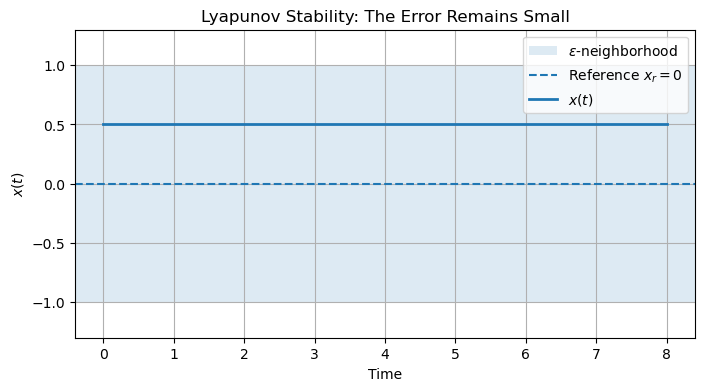

In [3]:
t = np.linspace(0, 8, 500)

epsilon = 1.0
x0 = 0.5

# x_dot = 0  ->  x(t) = x0
x = x0 * np.ones_like(t)

plt.figure(figsize=(8, 4))

# Allowed epsilon-neighborhood
plt.axhspan(-epsilon, epsilon, alpha=0.15, label=r"$\epsilon$-neighborhood")

# Reference
plt.axhline(0, linestyle="--", linewidth=1.5, label=r"Reference $x_r=0$")

# Motion
plt.plot(t, x, linewidth=2, label=r"$x(t)$")

plt.xlabel("Time")
plt.ylabel(r"$x(t)$")
plt.title("Lyapunov Stability: The Error Remains Small")
plt.ylim(-1.3, 1.3)
plt.legend()
plt.grid()
plt.show()

## 1.3.3 - Asymptotic Stability (Converge)

Asymptotic stability asks one step further than Lyapunov stability:

> If the motion starts close to the reference, does it not only stay close, but eventually return to it?

A motion $\mathbf{x}(t)$ is asymptotically stable relative to a reference motion $\mathbf{x}_r(t)$ if:

i) it is Lyapunov stable, and
ii) there exists some $\delta>0$ such that

$$
\mathbf{x}(t_0)\in B_\delta\bigl(\mathbf{x}r(t_0)\bigr)
\quad\Rightarrow\quad
\lim{t\rightarrow\infty}
\left|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right|
=0.
$$

<div align="center"> 
    <img src="Images/Wk1_AsymptoticStability.PNG" alt="Asymptotic convergence towards a reference motion" width="500"/> 
</div>

**<ins>Understanding the definition</ins>**

Asymptotic stability combines two properties:

$$
\boxed{
\text{Lyapunov stability}
+
\text{convergence}
}
$$

Lyapunov stability guarantees that a sufficiently small disturbance remains small.

Asymptotic stability additionally requires that the departure from the reference eventually vanishes:

$$
\mathbf{x}(t)-\mathbf{x}_r(t) \longrightarrow \mathbf{0}.
$$

The value $\delta$ defines a neighborhood of initial conditions from which this convergence is guaranteed.

**<ins>Geometric interpretation</ins>**

In the figure, the motion starts close to the reference trajectory and initially departs from it.

Unlike Lyapunov stability alone, however, the separation does not persist. As time increases, the blue trajectory approaches the reference trajectory until

$$
\left|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right|
\rightarrow 0.
$$

The trajectory may oscillate while doing this. What matters is that the size of the error eventually tends to zero.

**<ins>How this differs from Lyapunov stability</ins>**

Lyapunov stability says

$$
\text{start sufficiently close}
\quad\Rightarrow\quad
\text{remain close}.
$$

Asymptotic stability says

$$
\text{start sufficiently close}
\quad\Rightarrow\quad
\text{remain close and eventually converge}.
$$

For example, an undamped harmonic oscillator may be Lyapunov stable because small oscillations remain small, but they persist indefinitely.

With damping, the oscillations decay and the system approaches equilibrium, making the equilibrium asymptotically stable.

In summary:

$$
{
\text{stability}
+
\text{attraction}
}
$$

A sufficiently small disturbance remains controlled and eventually disappears. The next question is how large the set of initial conditions can be while retaining these guarantees; this leads to the distinction between local and global stability.

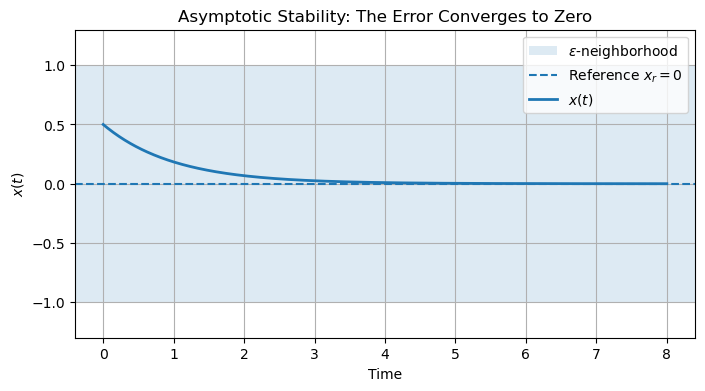

In [4]:
# x_dot = -x  ->  x(t) = x0 exp(-t)

x = x0 * np.exp(-t)

plt.figure(figsize=(8, 4))

plt.axhspan(-epsilon, epsilon, alpha=0.15, label=r"$\epsilon$-neighborhood")
plt.axhline(0, linestyle="--", linewidth=1.5, label=r"Reference $x_r=0$")

plt.plot(t, x, linewidth=2, label=r"$x(t)$")

plt.xlabel("Time")
plt.ylabel(r"$x(t)$")
plt.title("Asymptotic Stability: The Error Converges to Zero")
plt.ylim(-1.3, 1.3)
plt.legend()
plt.grid()
plt.show()

## 1.3.4 - Global Stability (Scope)

So far, our stability definitions have described how a system behaves. Global stability asks a different question:

> How much of the state space does that stability result apply to?

A stability result is global if the corresponding property holds for all admissible initial conditions in the state space.

For example, if

$$
\lim_{t\rightarrow\infty}
\left|
\mathbf{x}(t)-\mathbf{x}_r(t)
\right|
=0
$$

for every admissible initial state $\mathbf{x}(t_0)$, while the motion is also Lyapunov stable, then the reference motion is globally asymptotically stable.

In contrast, if the result is guaranteed only for initial conditions sufficiently close to the reference, then the result is local.

<div align="center"> 
    <img src="Images/Wk1_GlobalStability.PNG" alt="Local versus global stability in a nonlinear phase portrait" width="500"/> 
</div>

**<ins>Understanding the scope</ins>**

The distinction is therefore:

$$
\boxed{
\text{local}
\quad\Rightarrow\quad
\text{property holds near the reference}
}
$$

whereas

$$
\boxed{
\text{global}
\quad\Rightarrow\quad
\text{property holds throughout the admissible state space}
}
$$

This distinction matters especially for nonlinear systems because their behavior can change significantly as the state moves further away from an equilibrium.

**<ins>Interpreting the figure</ins>**

The figure shows the phase portrait of the nonlinear system

$$
\ddot{\omega}+\omega-\omega^3=0.
$$

Near the origin, the trajectories form bounded closed curves around the equilibrium. However, the behavior changes further away: beyond a certain region, trajectories are no longer confined around the origin.

The figure therefore illustrates an important point:

$$
\boxed{
\text{well-behaved locally}
\not\Rightarrow
\text{well-behaved globally}
}
$$

Looking only at motion close to the origin would miss the very different behavior elsewhere in the state space.

**<ins>Global asymptotic stability</ins>**

A particularly strong result is global asymptotic stability. It combines

$$
\text{Lyapunov stability}
+
\text{convergence}
+
\text{global scope}.
$$

A simple example is

$$
\dot{x}=-x.
$$

Its solution is

$$
x(t)=x(t_0)e^{-(t-t_0)},
$$

so for every finite initial condition,

$$
\lim_{t\rightarrow\infty}x(t)=0.
$$

The equilibrium $x=0$ is therefore globally asymptotically stable.

In summary:

Global stability does not introduce a new type of stability behavior. It tells us the scope over which a stability result is valid:

$$
\boxed{
\text{behavior}
+
\text{scope}
}
$$

For example, an equilibrium may be locally asymptotically stable or globally asymptotically stable depending on how large a set of initial conditions is guaranteed to converge to it.

# 1.4 - Linearization as a Local Stability analysis tool

Nonlinear systems are generally difficult to analyze directly.  
However, if the system dynamics are smooth, then near a reference motion the nonlinear vector field behaves approximately like a linear one.

Linearization provides a first-order approximation of the nonlinear dynamics in a neighborhood of a reference state or trajectory.  
This allows us to use linear tools — especially eigenvalue analysis — to assess **local stability**.

## 1.4.1 - Local Approximation and Geometric Interpretation

Nonlinear systems can behave very differently depending on where they are in the state space.

However, if we examine a nonlinear system **sufficiently close to a particular point or reference motion**, its behavior can often be approximated by something much simpler: a linear model.

The basic idea comes from the Taylor expansion.

Consider a scalar nonlinear function

$$
y = f(x).
$$

Suppose we are interested in its behavior near some reference point $x_r$.

We can write a nearby value of $x$ as

$$
x = x_r+\delta x,
$$

where $\delta x$ represents a small departure from the reference point.

The function can then be approximated by

$$
f(x_r+\delta x)
\approx
f(x_r)
+
\left.
\frac{df}{dx}
\right|_{x_r}
\delta x
+
\text{H.O.T.}
$$

where **H.O.T.** represents the higher-order terms of the Taylor expansion.

If $\delta x$ is sufficiently small, these higher-order terms become much smaller than the first-order term, so we neglect them:

$$
f(x_r+\delta x)
\approx
f(x_r)
+
\left.
\frac{df}{dx}
\right|_{x_r}
\delta x.
$$

**<ins>Geometric interpretation</ins>**

For a scalar function, this approximation is simply the **tangent line** to the nonlinear curve at $x_r$.

The derivative

$$
\left.
\frac{df}{dx}
\right|_{x_r}
$$

gives the slope of that tangent line.

Very close to $x_r$, the tangent line and the nonlinear function behave similarly.

As we move further away from $x_r$, the curvature of the nonlinear function becomes more important and the approximation becomes less accurate.

This is why linearization is fundamentally a **local approximation**:

$$
\boxed{
\text{nonlinear function}
\;\xrightarrow{\text{look sufficiently close}}\;
\text{approximately linear}
}
$$

**<ins>From one slope to many slopes</ins>**

For a dynamical system, things are usually more complicated because the state is a vector rather than a single number.

Consider

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}),
$$

where

$$
\mathbf{x} =
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_n
\end{bmatrix},
\qquad

\mathbf{f} =
\begin{bmatrix}
f_1\\
f_2\\
\vdots\\
f_n
\end{bmatrix}.
$$

Each equation $f_i$ may depend on several state variables and several control inputs.

There is therefore no longer just **one slope**.

For example, we may want to know:

- how $f_1$ changes when $x_1$ changes;
- how $f_1$ changes when $x_2$ changes;
- how $f_2$ changes when $x_1$ changes;
- and so on.

All of these local slopes are collected into a matrix called the **Jacobian matrix**.

**<ins>What is a Jacobian?</ins>**

For a scalar function,

$$
y=f(x),
$$

the derivative

$$
\frac{df}{dx}
$$

answers the question:

> If $x$ changes slightly, how much does $f$ change?

For a vector-valued function, we ask the same question for every combination of state and equation.

The Jacobian of $\mathbf{f}$ with respect to $\mathbf{x}$ is

$$
\frac{\partial\mathbf{f}}{\partial\mathbf{x}} =

\begin{bmatrix}
\frac{\partial f_1}{\partial x_1}
&
\frac{\partial f_1}{\partial x_2}
&
\cdots
&
\frac{\partial f_1}{\partial x_n}
\\[2mm]
\frac{\partial f_2}{\partial x_1}
&
\frac{\partial f_2}{\partial x_2}
&
\cdots
&
\frac{\partial f_2}{\partial x_n}
\\
\vdots & \vdots & \ddots & \vdots
\\
\frac{\partial f_n}{\partial x_1}
&
\frac{\partial f_n}{\partial x_2}
&
\cdots
&
\frac{\partial f_n}{\partial x_n}
\end{bmatrix}.
$$

Each element

$$
\frac{\partial f_i}{\partial x_j}
$$

has a simple interpretation:

> How sensitive is the $i$-th equation of motion to a small change in the $j$-th state?

The Jacobian can therefore be thought of as a **matrix of local sensitivities**. Its entries reveal how the states are locally coupled, with each term showing how a small change in one variable affects a particular equation of motion.

The same idea applies to the control input:

$$
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}.
$$

This tells us how the dynamics respond locally to small changes in the control input.

For linearization, these two Jacobians are usually written as

$$
A =
\frac{\partial\mathbf{f}}{\partial\mathbf{x}},
\qquad
B =
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}.
$$

So the simplest interpretation is

$$
\boxed{
A:
\text{ local sensitivity of the dynamics to the state}
}
$$

and

$$
\boxed{
B:
\text{ local sensitivity of the dynamics to the control input}
}
$$

The scalar derivative and the Jacobian are therefore really the same idea at different scales:

$$
\boxed{
\text{Derivative}
\rightarrow
\text{one local slope}
}
$$

$$
\boxed{
\text{Jacobian}
\rightarrow
\text{matrix of local slopes}
}
$$

Knowing the local slopes is only the first step.

For stability analysis, we are not ultimately interested in approximating $\mathbf{f}$ by itself. We want to know how a **small departure from a desired reference motion evolves with time**.

This requires us to define a reference motion and introduce the departure variables

$$
\delta\mathbf{x} =
\mathbf{x}-\mathbf{x}_r,
\qquad
\delta\mathbf{u} =
\mathbf{u}-\mathbf{u}_r.
$$

We can then use the Taylor approximation developed above to derive the equations governing

$$
\delta\dot{\mathbf{x}}.
$$

That is the purpose of the next section.

## 1.4.2 - Reference Motion and Local Error Dynamics

In the previous section, we saw that a nonlinear function can be approximated locally using its first-order Taylor expansion.

For stability analysis, however, we are not interested only in approximating the function itself. We want to know:

> **If the actual motion departs slightly from a desired reference motion, how does that departure evolve with time?**

Consider the nonlinear dynamical system

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}).
$$

Suppose we have a desired reference motion described by

$$
\mathbf{x}_r(t),
\qquad
\mathbf{u}_r(t).
$$

For this to be a valid reference motion of the system, it must itself satisfy the nonlinear equations of motion:

$$
\dot{\mathbf{x}}_r = \mathbf{f}(\mathbf{x}_r,\mathbf{u}_r).
$$

This is important. The reference trajectory is not just an arbitrary curve we would like the system to follow. It must represent a motion that is dynamically consistent with the system.

The input $\mathbf{u}_r$ can be thought of as the **nominal or feedforward input** required to generate the reference motion.

**<ins>Departure variables</ins>**

The actual state and control input may differ slightly from their reference values.

We describe these differences using the departure variables

$$
\delta\mathbf{x} = \mathbf{x}-\mathbf{x}_r,
$$

and

$$
\delta\mathbf{u} = \mathbf{u}-\mathbf{u}_r.
$$

Equivalently,

$$
\mathbf{x} =
\mathbf{x}_r+\delta\mathbf{x},
\qquad
\mathbf{u} =
\mathbf{u}_r+\delta\mathbf{u}.
$$

The interpretation is straightforward:

$$
\boxed{
\delta\mathbf{x} =
\text{departure of the actual state from the reference}
}
$$

and

$$
\boxed{
\delta\mathbf{u} =
\text{departure of the actual control input from the nominal input}
}
$$

In a feedback-control problem, $\delta\mathbf{u}$ is the corrective control action used to respond to the departure $\delta\mathbf{x}$.

The desired reference motion therefore corresponds to

$$
\delta\mathbf{x}=\mathbf{0}.
$$

So instead of studying the full motion $\mathbf{x}(t)$ directly, we can study whether the **error state** $\delta\mathbf{x}(t)$ remains small or returns to zero.

**<ins>Dynamics of the departure</ins>**

Differentiate the departure state:

$$
\delta\dot{\mathbf{x}} = \dot{\mathbf{x}} - \dot{\mathbf{x}}_r.
$$

Using the nonlinear equations of motion,

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}),
$$

and the reference dynamics,

$$
\dot{\mathbf{x}}_r = \mathbf{f}(\mathbf{x}_r,\mathbf{u}_r),
$$

we obtain

$$
\delta\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) - \mathbf{f}(\mathbf{x}_r,\mathbf{u}_r).
$$

Now substitute

$$
\mathbf{x} =
\mathbf{x}_r+\delta\mathbf{x},
\qquad
\mathbf{u} =
\mathbf{u}_r+\delta\mathbf{u},
$$

giving

$$
\delta\dot{\mathbf{x}} =
\mathbf{f}
\left(\mathbf{x}_r+\delta\mathbf{x}, \mathbf{u}_r+\delta\mathbf{u}\right) - \mathbf{f}(\mathbf{x}_r,\mathbf{u}_r).
$$

At this point the equation is still fully nonlinear.

This is where the local approximation developed in the previous section becomes useful.

**<ins>Linearising about the reference motion</ins>**

Using a first-order Taylor expansion about

$$
(\mathbf{x}_r,\mathbf{u}_r),
$$

we obtain

$$
\mathbf{f}
\left(
\mathbf{x}_r+\delta\mathbf{x},
\mathbf{u}_r+\delta\mathbf{u}
\right)
\approx
\mathbf{f}(\mathbf{x}_r,\mathbf{u}_r) +
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{x}}
\right|_r
\delta\mathbf{x} +
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}
\right|_r
\delta\mathbf{u} +
\text{H.O.T.}
$$

Substitute this into the departure dynamics:

$$
\delta\dot{\mathbf{x}}
\approx
\left[
\mathbf{f}(\mathbf{x}_r,\mathbf{u}_r) +
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{x}}
\right|_r
\delta\mathbf{x} +
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}
\right|_r
\delta\mathbf{u} +
\text{H.O.T.}
\right] -
\mathbf{f}(\mathbf{x}_r,\mathbf{u}_r).
$$

The nominal terms cancel:

$$
\mathbf{f}(\mathbf{x}_r,\mathbf{u}_r) - \mathbf{f}(\mathbf{x}_r,\mathbf{u}_r) = \mathbf{0}.
$$

Neglecting the higher-order terms for sufficiently small departures leaves

$$
\delta\dot{\mathbf{x}}
\approx
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{x}}
\right|_r
\delta\mathbf{x}
+
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}
\right|_r
\delta\mathbf{u}.
$$

Using the Jacobian notation introduced previously,

$$
A(t) =
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{x}}
\right|_{(\mathbf{x}_r,\mathbf{u}_r)},
$$

$$
B(t) =
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}
\right|_{(\mathbf{x}_r,\mathbf{u}_r)},
$$

the local error dynamics become

$$
\boxed{
\delta\dot{\mathbf{x}}
\approx
A(t)\delta\mathbf{x}
+
B(t)\delta\mathbf{u}
}
$$

This is the **linearized system governing small departures from the reference motion**.

**<ins>What did we actually accomplish?</ins>**

We started with the nonlinear dynamics

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}),
$$

but instead of trying to describe the complete nonlinear motion everywhere, we asked how a small error around a chosen reference behaves.

The result is

$$
\boxed{
\text{nonlinear full-state dynamics}
\quad\longrightarrow\quad
\text{linear local error dynamics}
}
$$

The matrices $A$ and $B$ capture the local behavior of the nonlinear system along the reference motion.

Because the reference quantities $\mathbf{x}_r(t)$ and $\mathbf{u}_r(t)$ may change with time, the Jacobians evaluated along that motion may also change with time. This is why they have been written as $A(t)$ and $B(t)$ here.

The approximation is valid only while

$$
\delta\mathbf{x}
\quad\text{and}\quad
\delta\mathbf{u}
$$

remain sufficiently small for the neglected higher-order terms to remain insignificant.

A particularly important special case occurs when the reference motion is not moving at all, but is instead an **equilibrium point**.

That case simplifies the linearized equations considerably and is the subject of the next section.

## 1.4.3 - Linearization about an Equilibrium

The previous section considered linearization about a general reference motion

$$
\mathbf{x}_r(t),
\qquad
\mathbf{u}_r(t),
$$

which may change with time.

An **equilibrium** is a particularly important special case because the reference state is constant.

Let

$$
\mathbf{x}_r(t) = \mathbf{x}_e,
\qquad
\mathbf{u}_r(t) = \mathbf{u}_e,
$$

where $\mathbf{x}_e$ and $\mathbf{u}_e$ satisfy

$$
\mathbf{f}(\mathbf{x}_e,\mathbf{u}_e)=\mathbf{0}.
$$

Since the state remains constant at equilibrium,

$$
\dot{\mathbf{x}}_e=\mathbf{0}.
$$

The departure variables are therefore

$$
\delta\mathbf{x} =
\mathbf{x}-\mathbf{x}_e,

\qquad

\delta\mathbf{u} =
\mathbf{u}-\mathbf{u}_e.
$$

From the previous section, the local departure dynamics are

$$
\delta\dot{\mathbf{x}} \approx A,\delta\mathbf{x} + B,\delta\mathbf{u},
$$

where the Jacobians are now evaluated at the equilibrium:

$$
A =
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{x}}
\right|_{(\mathbf{x}_e,\mathbf{u}_e)},

\qquad

B =
\left.
\frac{\partial\mathbf{f}}{\partial\mathbf{u}}
\right|_{(\mathbf{x}_e,\mathbf{u}_e)}.
$$

Because the equilibrium is fixed, these matrices are constant provided the original system has no explicit time dependence.

**<ins>Why the equilibrium case is simpler</ins>**

For a general reference motion, the operating point moves through the state space:

$$
\mathbf{x}_r = \mathbf{x}_r(t).
$$

The Jacobians must therefore be repeatedly evaluated along that motion, giving

$$
A(t),
\qquad
B(t).
$$

At an equilibrium, however, the operating point does not move:

$$
\mathbf{x}_e = \text{constant}.
$$

The local model therefore becomes a linear time-invariant system:

$$
\boxed{
\delta\dot{\mathbf{x}} \approx A\delta\mathbf{x} + B\delta\mathbf{u}
}
$$

for an autonomous nonlinear system linearized about a fixed equilibrium.

This is extremely useful because all of the familiar tools for linear systems can now be applied to the **local error dynamics**.

**<ins>Why the perturbation variables are still important</ins>**

The equilibrium does not have to be located at the origin.

For example,

$$
\mathbf{x}_e =
\begin{bmatrix}
5\
2
\end{bmatrix}
$$

is just as valid an equilibrium as

$$
\mathbf{x}_e = 
\begin{bmatrix}
0\
0
\end{bmatrix}.
$$

The linearized model describes the departure

$$
\delta\mathbf{x} = \mathbf{x}-\mathbf{x}_e,
$$

not necessarily the original state $\mathbf{x}$ itself.

It is common to **shift the coordinates** so that the equilibrium becomes the origin:

$$
\tilde{\mathbf{x}} = \mathbf{x}-\mathbf{x}_e,
\qquad
\tilde{\mathbf{u}} = \mathbf{u}-\mathbf{u}_e.
$$

Then

$$
\mathbf{x}=\mathbf{x}_e
\quad\Longleftrightarrow\quad
\tilde{\mathbf{x}}=\mathbf{0}.
$$

If we subsequently relabel the shifted variables as $\mathbf{x}$ and $\mathbf{u}$ for convenience, the linearized equations are often written simply as

$$
\dot{\mathbf{x}} \approx A\mathbf{x} + B\mathbf{u}.
$$

This is the shorthand used in many control texts and in the course slides. The important point is that these variables should now be interpreted as **departures from the equilibrium**, not necessarily the original physical state and input.

**<ins>For stability analysis</ins>**

If there is no departure in the control input,

$$
\delta\mathbf{u}=\mathbf{0},
$$

the local dynamics reduce to

$$
\boxed{
\delta\dot{\mathbf{x}} \approx A\delta\mathbf{x}
}
$$

The question

> **Is the nonlinear equilibrium stable?**

has therefore been converted into the local linear question

> **What happens to small perturbations governed by the matrix $A$?**

This is where the eigenvalues of $A$ become useful, which leads directly into the next section.

## 1.4.4 - Stability of Linearized System

After linearizing about an equilibrium, the local uncontrolled error dynamics take the form

$$
\delta\dot{\mathbf{x}} = A\delta\mathbf{x}.
$$

We have therefore converted the original nonlinear stability problem into a familiar linear one:

> **What happens to a small perturbation $\delta\mathbf{x}$ under the dynamics defined by $A$?**

For a linear time-invariant system, this behavior is determined by the **eigenvalues of $A$**.


**<ins>Why do the eigenvalues matter?</ins>**

The solution of

$$
\delta\dot{\mathbf{x}} = A\delta\mathbf{x}
$$

is

$$
\delta\mathbf{x}(t) = e^{A(t-t_0)} \delta\mathbf{x}(t_0).
$$

The eigenvalues of $A$ determine the basic modes contained within this solution.

Each mode behaves roughly like

$$
e^{\lambda_i t},
$$

where $\lambda_i$ is an eigenvalue of $A$.

If

$$
\lambda_i = \sigma_i+j\omega_i,
$$

then

$$
e^{\lambda_i t} = e^{\sigma_i t}e^{j\omega_i t}.
$$

This separates the behavior into two useful parts:

$$
\boxed{
\operatorname{Re}(\lambda_i)=\sigma_i
\rightarrow
\text{growth or decay}
}
$$

and

$$
\boxed{
\operatorname{Im}(\lambda_i)=\omega_i
\rightarrow
\text{oscillation}
}
$$

The **real part** is therefore the part that determines stability.


**<ins>Case 1: All eigenvalues have negative real parts</ins>**

If

$$
\operatorname{Re}(\lambda_i)<0
\qquad
\forall i,
$$

then every mode decays exponentially with time.

Therefore,

$$
\delta\mathbf{x}(t)\rightarrow\mathbf{0}
\qquad
\text{as}
\qquad
t\rightarrow\infty.
$$

For the linearized system, the origin is exponentially stable.

More importantly, when $A$ is obtained by linearizing a sufficiently smooth nonlinear system about an equilibrium, this allows us to conclude that the **nonlinear equilibrium is locally exponentially stable**, and therefore locally asymptotically stable.

Thus,

$$
\boxed{
\operatorname{Re}(\lambda_i)<0
\;\forall i
\quad\Rightarrow\quad
\text{locally stable and convergent nonlinear motion}
}
$$

The word **locally** is important because the matrix $A$ only describes the first-order behavior near the equilibrium.


**<ins>Case 2: At least one eigenvalue has a positive real part</ins>**

If

$$
\operatorname{Re}(\lambda_i)>0
$$

for at least one eigenvalue, then the corresponding mode contains an exponentially growing term.

A sufficiently small perturbation in that direction can therefore grow away from the equilibrium.

Hence,

$$
\boxed{
\exists\,\lambda_i:
\operatorname{Re}(\lambda_i)>0
\quad\Rightarrow\quad
\text{unstable equilibrium}
}
$$

In this case, the linearization is enough to establish instability of the nonlinear equilibrium.


**<ins>Case 3: Eigenvalues lie on the imaginary axis</ins>**

The interesting case occurs when no eigenvalue has a positive real part, but one or more satisfy

$$
\operatorname{Re}(\lambda_i)=0.
$$

For example,

$$
\lambda=\pm j\omega
$$

produces an oscillatory mode without exponential growth or decay in the linear model.

It may be tempting to conclude that the nonlinear equilibrium is therefore Lyapunov stable.

However, this conclusion cannot generally be made.

The reason is that when the first-order dynamics neither grow nor decay, the higher-order nonlinear terms that were neglected during linearization may determine the actual behavior.

Therefore,

$$
\boxed{
\operatorname{Re}(\lambda_i)=0
\text{ for one or more modes}
\quad\Rightarrow\quad
\text{linearization is generally inconclusive}
}
$$

The actual nonlinear system may be stable, asymptotically stable, or unstable depending on the neglected nonlinear terms.

This is one of the main reasons why nonlinear stability tools such as Lyapunov's direct method are needed.

**<ins>Including feedback control</ins>**

If the local linearized system includes a control input,

$$
\delta\dot{\mathbf{x}} = A\delta\mathbf{x} + B\delta\mathbf{u},
$$

and we apply linear state feedback

$$
\delta\mathbf{u} = -K\delta\mathbf{x},
$$

then

$$
\delta\dot{\mathbf{x}} = A\delta\mathbf{x} - BK\delta\mathbf{x},
$$

so that

$$
\boxed{
\delta\dot{\mathbf{x}} = (A-BK)\delta\mathbf{x}
}
$$

The matrix

$$
A_{\mathrm{cl}} = A-BK
$$

is the **closed-loop system matrix**.

Stability is therefore determined by the eigenvalues of $A_{\mathrm{cl}}$, rather than those of the uncontrolled matrix $A$.

This connects directly back to the basic idea of feedback introduced earlier:

$$
\boxed{
\text{feedback reshapes the dynamics}
}
$$

The controller $K$ changes the local closed-loop dynamics and therefore changes the locations of the eigenvalues.

**<ins>Linear system versus linearized nonlinear system</ins>**

There is one distinction that must be kept clear.

If

$$
\dot{\mathbf{x}}=A\mathbf{x}
$$

is the **actual mathematical model of a linear system**, then the eigenvalue conclusions describe that linear model globally.

For example,

$$
\operatorname{Re}(\lambda_i)<0
\qquad
\forall i
$$

implies global exponential stability of the equilibrium of that linear system.

But when

$$
A =
\left.
\frac{\partial\mathbf{f}}
{\partial\mathbf{x}}
\right|_{\mathbf{x}_e}
$$

comes from linearizing a nonlinear system, $A$ only represents the dynamics close to $\mathbf{x}_e$.

Therefore,

$$
\boxed{
\text{global result for the linear model}
\;\not\Rightarrow\;
\text{global result for the nonlinear system}
}
$$

What we obtain from the linearization is generally a **local statement about the nonlinear equilibrium**.

**In summary:**

For a nonlinear system linearized about an equilibrium,

$$
\delta\dot{\mathbf{x}}
\approx
A\delta\mathbf{x},
$$

the eigenvalues of $A$ provide the following local test:

$$
\boxed{
\begin{array}{rcl}
\operatorname{Re}(\lambda_i)<0\ \forall i
&\Rightarrow&
\text{locally exponentially stable}
\\[2mm]
\exists\,\lambda_i:\operatorname{Re}(\lambda_i)>0
&\Rightarrow&
\text{unstable}
\\[2mm]
\operatorname{Re}(\lambda_i)\leq0
\text{ with at least one }=0
&\Rightarrow&
\text{linearization generally inconclusive}
\end{array}
}
$$

Linearization can therefore give very strong local stability conclusions, but only when the eigenvalues give a decisive answer.

The remaining question is:

> **How much can we trust this linear model as we move farther away from the equilibrium?**

That is the limitation we examine in the next section.

## 1.4.5 - What Linearization can and cannot tell us

Linearization is powerful because it allows us to use familiar linear-system tools to study a nonlinear system.

However, the result must be interpreted correctly.

When we linearize

$$
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u})
$$

about a reference motion or equilibrium, we replace the full nonlinear dynamics with the first-order approximation

$$
\delta\dot{\mathbf{x}} \approx A\,\delta\mathbf{x} + B\,\delta\mathbf{u}.
$$

The higher-order nonlinear terms have been neglected.

Therefore, the linearized model is not a replacement for the nonlinear system. It is a model of its behavior **near the point about which the linearization was performed**.

**<ins>Why the approximation is local</ins>**

The Taylor expansion can be thought of schematically as

$$
\mathbf{f} = \mathbf{f}_r + A\,\delta\mathbf{x} + B\,\delta\mathbf{u} + \text{H.O.T.}
$$

When

$$
\delta\mathbf{x}
\approx\mathbf{0},
\qquad
\delta\mathbf{u}
\approx\mathbf{0},
$$

the higher-order terms are small and the first-order approximation can describe the nonlinear dynamics well.

As the departure becomes larger, the neglected terms become increasingly important.

Therefore,

$$
\boxed{
\text{small departure}
\rightarrow
\text{linear and nonlinear models behave similarly}
}
$$

while

$$
\boxed{
\text{large departure}
\rightarrow
\text{nonlinear effects may dominate}
}
$$

There is generally no single distance from the equilibrium at which a linearization suddenly becomes invalid. Its usefulness depends on the nonlinear system, the operating point, and the accuracy required.

**<ins>What linearization can tell us</ins>**

A linearization provides several useful pieces of information about the system near the chosen reference.

The Jacobian matrices

$$
A = \frac{\partial\mathbf{f}}{\partial\mathbf{x}},
\qquad
B = \frac{\partial\mathbf{f}}{\partial\mathbf{u}}
$$

describe the local sensitivity and first-order coupling of the dynamics.

Around an equilibrium, the eigenvalues of $A$ can also provide decisive local stability information.

For example,

$$
\operatorname{Re}(\lambda_i)<0
\qquad
\forall i
$$

allows us to conclude that the nonlinear equilibrium is locally exponentially stable, while the presence of an eigenvalue with

$$
\operatorname{Re}(\lambda_i)>0
$$

establishes instability.

Linearization is therefore extremely useful for

$$
\boxed{
\text{understanding and controlling small departures around an operating point}
}
$$

**<ins>What linearization cannot tell us</ins>**

A locally accurate model does not automatically describe the behavior of the nonlinear system throughout the state space.

In particular, linearization alone does not generally tell us:

- how large the region of validity of the approximation is;
- whether a locally stable equilibrium is globally stable;
- what happens near other equilibria;
- whether important nonlinear behavior appears farther from the reference;
- or what the nonlinear system does when the linearization is inconclusive.

This means that

$$
\boxed{
\text{stable linearization}
\;\not\Rightarrow\;
\text{globally stable nonlinear system}
}
$$

The linearized model may be stable everywhere as a mathematical linear system, while the nonlinear system from which it was derived may only behave similarly in a small region around the equilibrium.

**<ins>A simple example</ins>**

Consider the nonlinear scalar system

$$
\dot{x} = -x + x^3.
$$

Define

$$
f(x) = -x + x^3.
$$

We will linearize the system about the equilibrium

$$
x_e = 0.
$$

First, verify that $x_e=0$ is indeed an equilibrium:

$$
f(0) = -(0) + (0)^3 = 0.
$$

Therefore,

$$
\boxed{x_e=0}
$$

is an equilibrium point.

**<ins>Define the departure from the equilibrium</ins>**

The departure variable is

$$
\delta x = x-x_e.
$$

Since

$$
x_e=0,
$$

we have

$$
\delta x=x.
$$

Therefore,

$$
x=\delta x.
$$

Because the equilibrium is constant,

$$
\dot{x}_e=0,
$$

and hence

$$
\delta\dot{x} = \dot{x}-\dot{x}_e = \dot{x}.
$$

Substituting

$$
x=\delta x
$$

into the original nonlinear dynamics gives the **exact departure dynamics**

$$
\delta\dot{x} = -\delta x + (\delta x)^3.
$$

At this stage, the system is still nonlinear because of the cubic term

**<ins>Linearize the departure dynamics</ins>**

Linearization keeps only the first-order behavior around the equilibrium.

The term

$$
-\delta x
$$

is first order in $\delta x$, while

$$
(\delta x)^3
$$

is third order.

When $\delta x$ is sufficiently small,

$$
(\delta x)^3
\ll
\delta x.
$$

Therefore, close to the equilibrium, the cubic term can be neglected:

$$
\delta\dot{x} = -\delta x + (\delta x)^3
$$

becomes

$$
\boxed{
\delta\dot{x} \approx -\delta x
}
$$

which is the linearized system.


**<ins>The same result using the Jacobian</ins>**

The general linearization about an equilibrium is

$$
\delta\dot{x}
\approx
A\delta x,
$$

where

$$
A =
\left.
\frac{df}{dx}
\right|_{x=x_e}.
$$

For

$$
f(x) =
-x+x^3,
$$

the derivative is

$$
\frac{df}{dx} =
-1+3x^2.
$$

Evaluating this at

$$
x_e=0
$$

gives

$$
A =
-1+3(0)^2 = -1.
$$

Therefore,

$$
\delta\dot{x}
\approx
A\delta x
$$

becomes

$$
\boxed{
\delta\dot{x}
\approx
-\delta x
}.
$$

The Jacobian method and the direct Taylor-expansion interpretation therefore give exactly the same local model.


**<ins>What does the linearized model predict?</ins>**

The linearized differential equation is

$$
\delta\dot{x} = -\delta x.
$$

Its solution is

$$
\delta x(t) = \delta x(0)e^{-t}.
$$

Since

$$
e^{-t}
\rightarrow
0
\qquad
\text{as}
\qquad
t\rightarrow\infty,
$$

we obtain

$$
\delta x(t)\rightarrow0.
$$

Therefore, the linearized model predicts exponential convergence toward the equilibrium.

Equivalently, the linearized system matrix is simply

$$
A=-1,
$$

with eigenvalue

$$
\lambda=-1.
$$

Since

$$
\operatorname{Re}(\lambda)<0,
$$

the equilibrium is locally exponentially stable.


**<ins>Why is this only a local result?</ins>**

Near

$$
x=0,
$$

the nonlinear term is much smaller than the linear term.

For example, if

$$
x=0.1,
$$

then

$$
x^3=0.001.
$$

The nonlinear dynamics give

$$
\dot{x} = -0.1+0.001 = -0.099,
$$

while the linearized model gives

$$
\dot{x} \approx -0.1.
$$

The two predictions are almost identical.

However, if

$$
x=0.8,
$$

then

$$
x^3=0.512,
$$

so the nonlinear dynamics give

$$
\dot{x} = -0.8+0.512 = -0.288,
$$

while the linearized model still predicts

$$
\dot{x}
\approx
-0.8.
$$

The difference is now much larger because the cubic term is no longer negligible.

Therefore,

$$
\boxed{
\text{closer to }x_e
\;\Rightarrow\;
\text{better linear approximation}
}
$$

**<ins>The nonlinear system contains more information</ins>**

The equilibria of the full nonlinear system satisfy

$$
-x+x^3=0.
$$

Factorizing,

$$
x(x^2-1)=0,
$$

or

$$
x(x-1)(x+1)=0.
$$

Therefore, the nonlinear system has three equilibria:

$$
\boxed{
x_e=-1,\quad0,\quad1
}
$$

The linearized model about $x_e=0$,

$$
\delta\dot{x} = -\delta x,
$$

does not reveal the equilibria at

$$
x=\pm1.
$$

This is because the linearized model only captures the first-order behavior in the neighborhood of the specific equilibrium about which it was constructed.

The example therefore illustrates the central limitation of linearization:

$$
\boxed{
\text{linearization describes local behavior well,
but does not preserve the full global structure of the nonlinear system}
}
$$

This will be shown by means of code below...

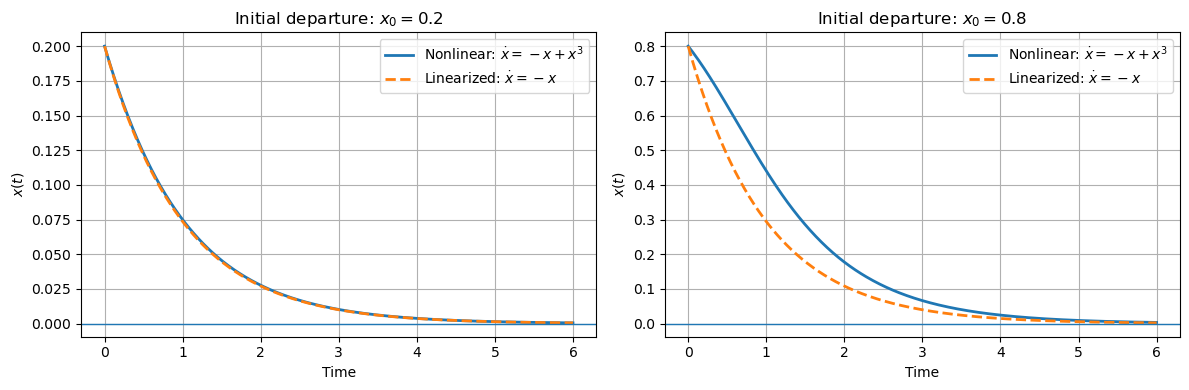

In [5]:
# Nonlinear system:
#
#     x_dot = -x + x^3
#
# Equilibrium used for linearization:
#
#     x_e = 0
#
# Departure from the equilibrium:
#
#     delta_x = x - x_e
#
# Since x_e = 0:
#
#     delta_x = x
#
# The exact departure dynamics are therefore:
#
#     delta_x_dot = -delta_x + delta_x^3
#
# Close to the equilibrium, delta_x^3 is small compared with delta_x,
# so the first-order linearized dynamics are:
#
#     delta_x_dot ≈ -delta_x
#
# The Jacobian gives the same result:
#
#     A = df/dx = -1 + 3x^2
#     A(x_e = 0) = -1
#
# Therefore:
#
#     delta_x_dot = A delta_x = -delta_x
#
# whose analytical solution is:
#
#     delta_x(t) = delta_x(0) exp(-t)


def nonlinear_dynamics(t, x):
    return -x + x**3


t = np.linspace(0.0, 6.0, 500)

# Compare a small departure with a larger departure.
initial_conditions = [0.2, 0.8]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))


for ax, x0 in zip(axes, initial_conditions):

    # Full nonlinear solution:
    #
    #     x_dot = -x + x^3
    nonlinear_solution = solve_ivp(
        nonlinear_dynamics,
        t_span=(t[0], t[-1]),
        y0=[x0],
        t_eval=t
    )

    x_nonlinear = nonlinear_solution.y[0]

    # Linearized solution:
    #
    #     delta_x_dot = -delta_x
    #
    # Because x_e = 0, delta_x(0) = x0.
    x_linear = x0 * np.exp(-t)

    ax.plot(
        t,
        x_nonlinear,
        linewidth=2,
        label=r"Nonlinear: $\dot{x}=-x+x^3$"
    )

    ax.plot(
        t,
        x_linear,
        "--",
        linewidth=2,
        label=r"Linearized: $\dot{x}=-x$"
    )

    # Equilibrium about which the system was linearized.
    ax.axhline(0.0, linewidth=1)

    ax.set_xlabel("Time")
    ax.set_ylabel(r"$x(t)$")
    ax.set_title(fr"Initial departure: $x_0={x0}$")
    ax.grid()
    ax.legend()


plt.tight_layout()
plt.show()

**<ins>The main idea</ins>**

Linearization should therefore be interpreted as a **local lens** through which we examine a nonlinear system.

It converts

$$
\boxed{
\dot{\mathbf{x}} = \mathbf{f}(\mathbf{x},\mathbf{u})
}
$$

into the much simpler local model

$$
\boxed{
\delta\dot{\mathbf{x}}
\approx
A\,\delta\mathbf{x}
+
B\,\delta\mathbf{u}
}
$$

which allows us to apply linear control and stability tools.

But the conclusions must remain consistent with the approximation from which they came:

$$
\boxed{
\text{local model}
\rightarrow
\text{local conclusions}
}
$$

When the behavior farther from the reference matters, or when the linearized system cannot determine stability, the nonlinear dynamics must be considered directly.

This motivates the use of nonlinear stability methods such as **Lyapunov's direct method**, which allow stability to be studied without replacing the nonlinear dynamics with a local linear approximation.

---

Notes compiled and structured by John Gracious